In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import TwoSlopeNorm 
from scipy.optimize import curve_fit
import seaborn as sns
import pandas as pd
import parana_theme as tema
tema.aplicar_tema()

In [2]:
K_VALUES = [0.5, 0.971635, 1.5, 6.47] 
H5_FILENAME = '../dat/lyapunov_exponents.h5'
#OUTPUT_PDF = '../plots/standard_map_displacement.pdf'

In [3]:
df = pd.DataFrame()
for k_val in K_VALUES:
    with h5py.File(H5_FILENAME, 'r') as f:
        dset_name = f"K_{k_val:.6f}"
        data = f[dset_name][:]
    data = pd.DataFrame(np.reshape(data, (-1))).transpose().melt(var_name='Part', value_name=f'K_{k_val:.6f}')
    df = pd.concat([df, data], axis=1)
   #df = pd.DataFrame(data).transpose()

In [4]:
df

,Part,K_0.500000,Part,K_0.971635,Part,K_1.500000,Part,K_6.470000
0,0,0.000151,0,0.000081,0,0.000149,0,1.217590
1,1,0.000151,1,0.000098,1,0.000069,1,1.223803
2,2,0.000145,2,0.000129,2,0.000100,2,1.229834
3,3,0.000117,3,0.000140,3,0.000250,3,1.199775
4,4,0.000046,4,0.000060,4,0.000286,4,1.203306
...,...,...,...,...,...,...,...,...
1048571,1048571,0.000046,1048571,0.000060,1048571,0.000286,1048571,1.196489
1048572,1048572,0.000117,1048572,0.000140,1048572,0.000250,1048572,1.218786
1048573,1048573,0.000145,1048573,0.000129,1048573,0.000100,1048573,1.172032
1048574,1048574,0.000151,1048574,0.000098,1048574,0.000069,1048574,1.196637


In [5]:
df_test = df.drop(columns=['Part'])

In [6]:
df_test

,K_0.500000,K_0.971635,K_1.500000,K_6.470000
0,0.000151,0.000081,0.000149,1.217590
1,0.000151,0.000098,0.000069,1.223803
2,0.000145,0.000129,0.000100,1.229834
3,0.000117,0.000140,0.000250,1.199775
4,0.000046,0.000060,0.000286,1.203306
...,...,...,...,...
1048571,0.000046,0.000060,0.000286,1.196489
1048572,0.000117,0.000140,0.000250,1.218786
1048573,0.000145,0.000129,0.000100,1.172032
1048574,0.000151,0.000098,0.000069,1.196637


<Axes: ylabel='Density'>

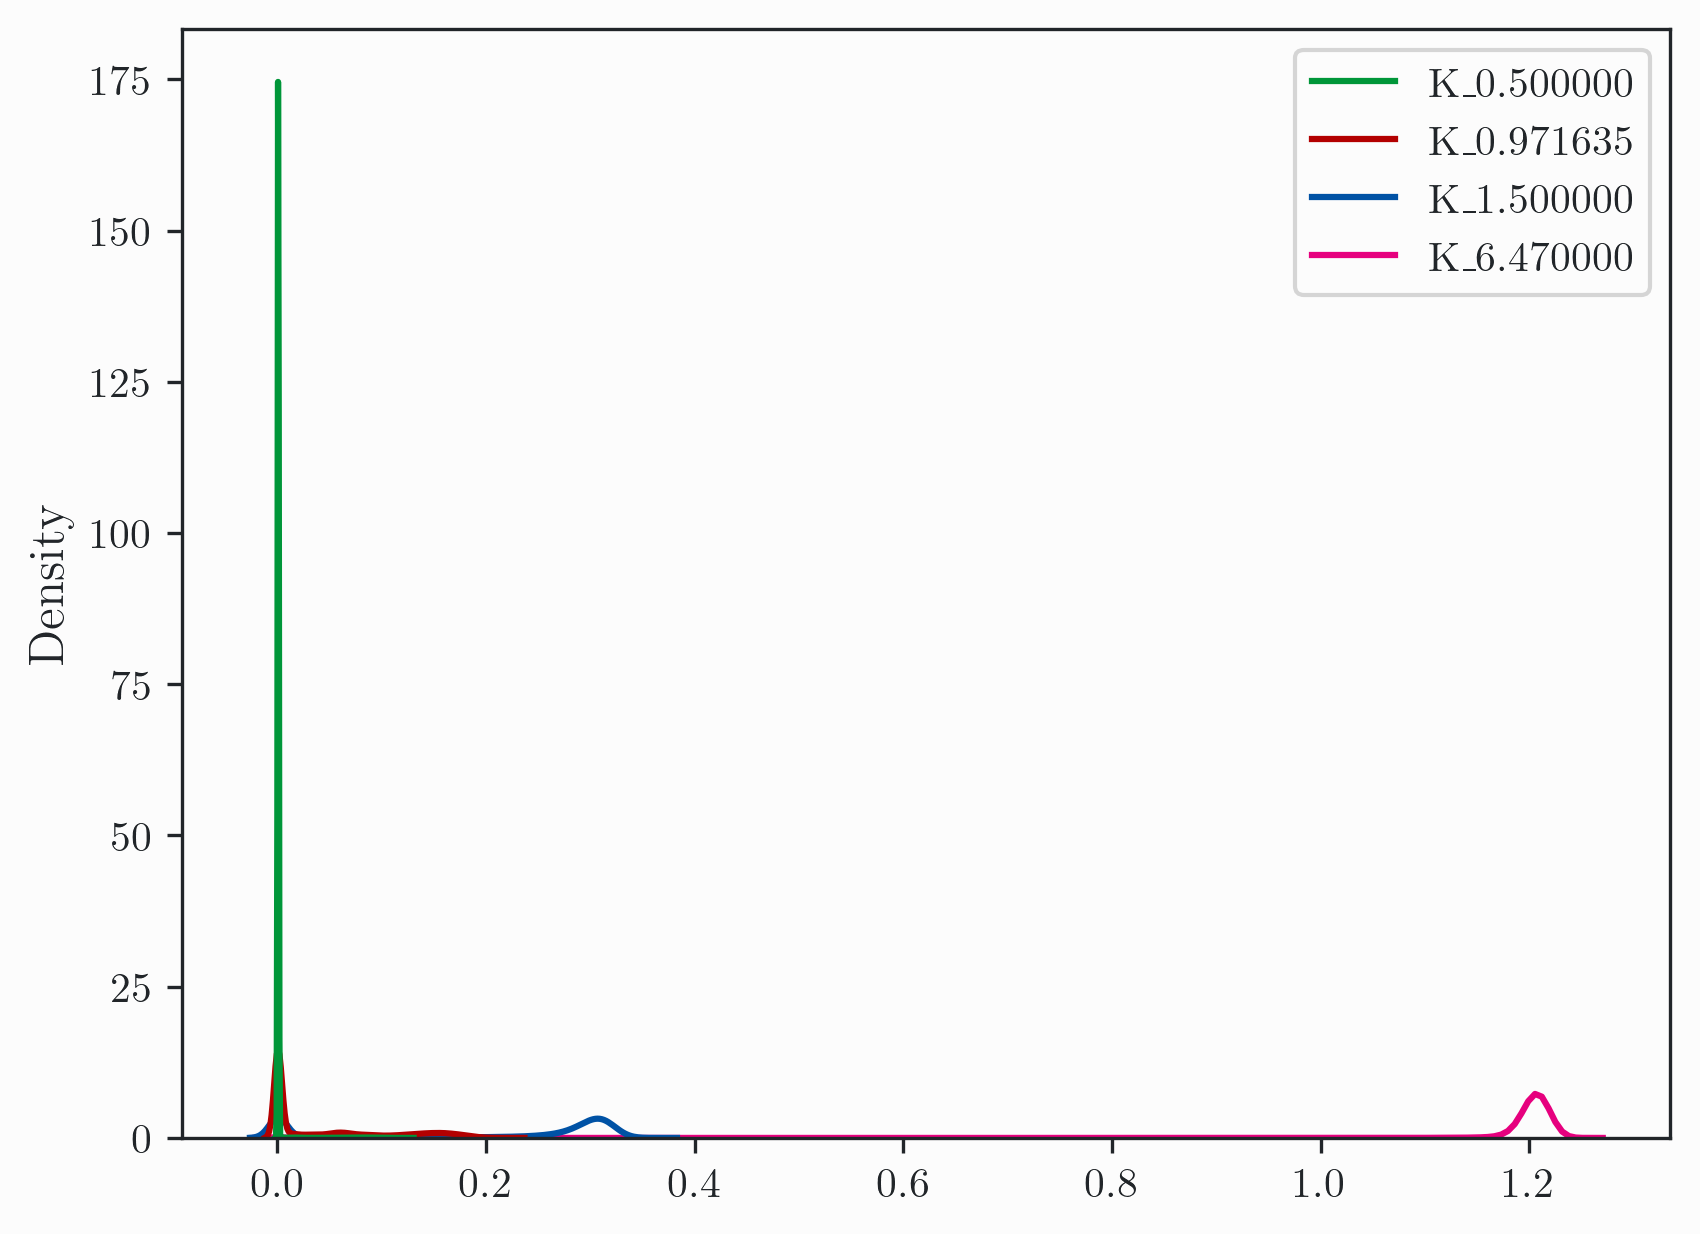

<Axes: >

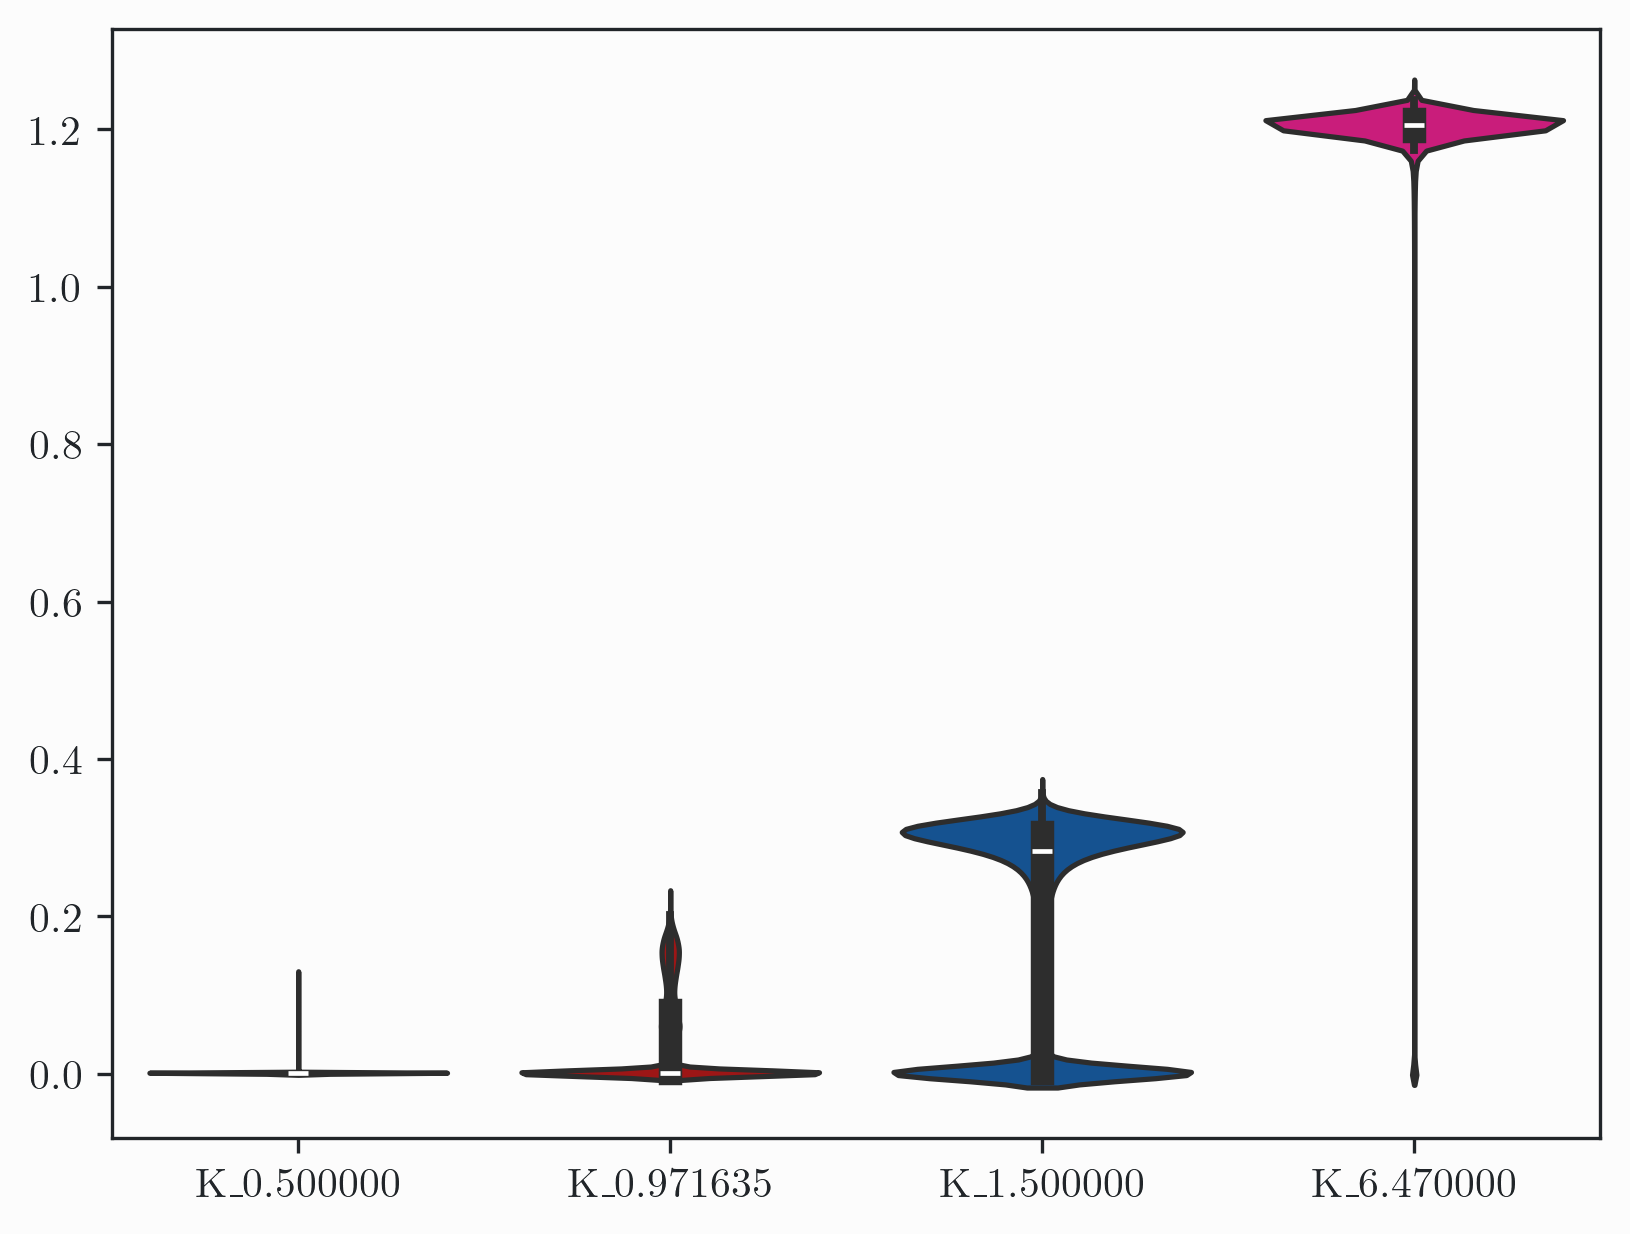

In [11]:
sns.violinplot(data=df_test,common_norm=False)

<Axes: label='D', xlabel='K_6.470000', ylabel='Density'>

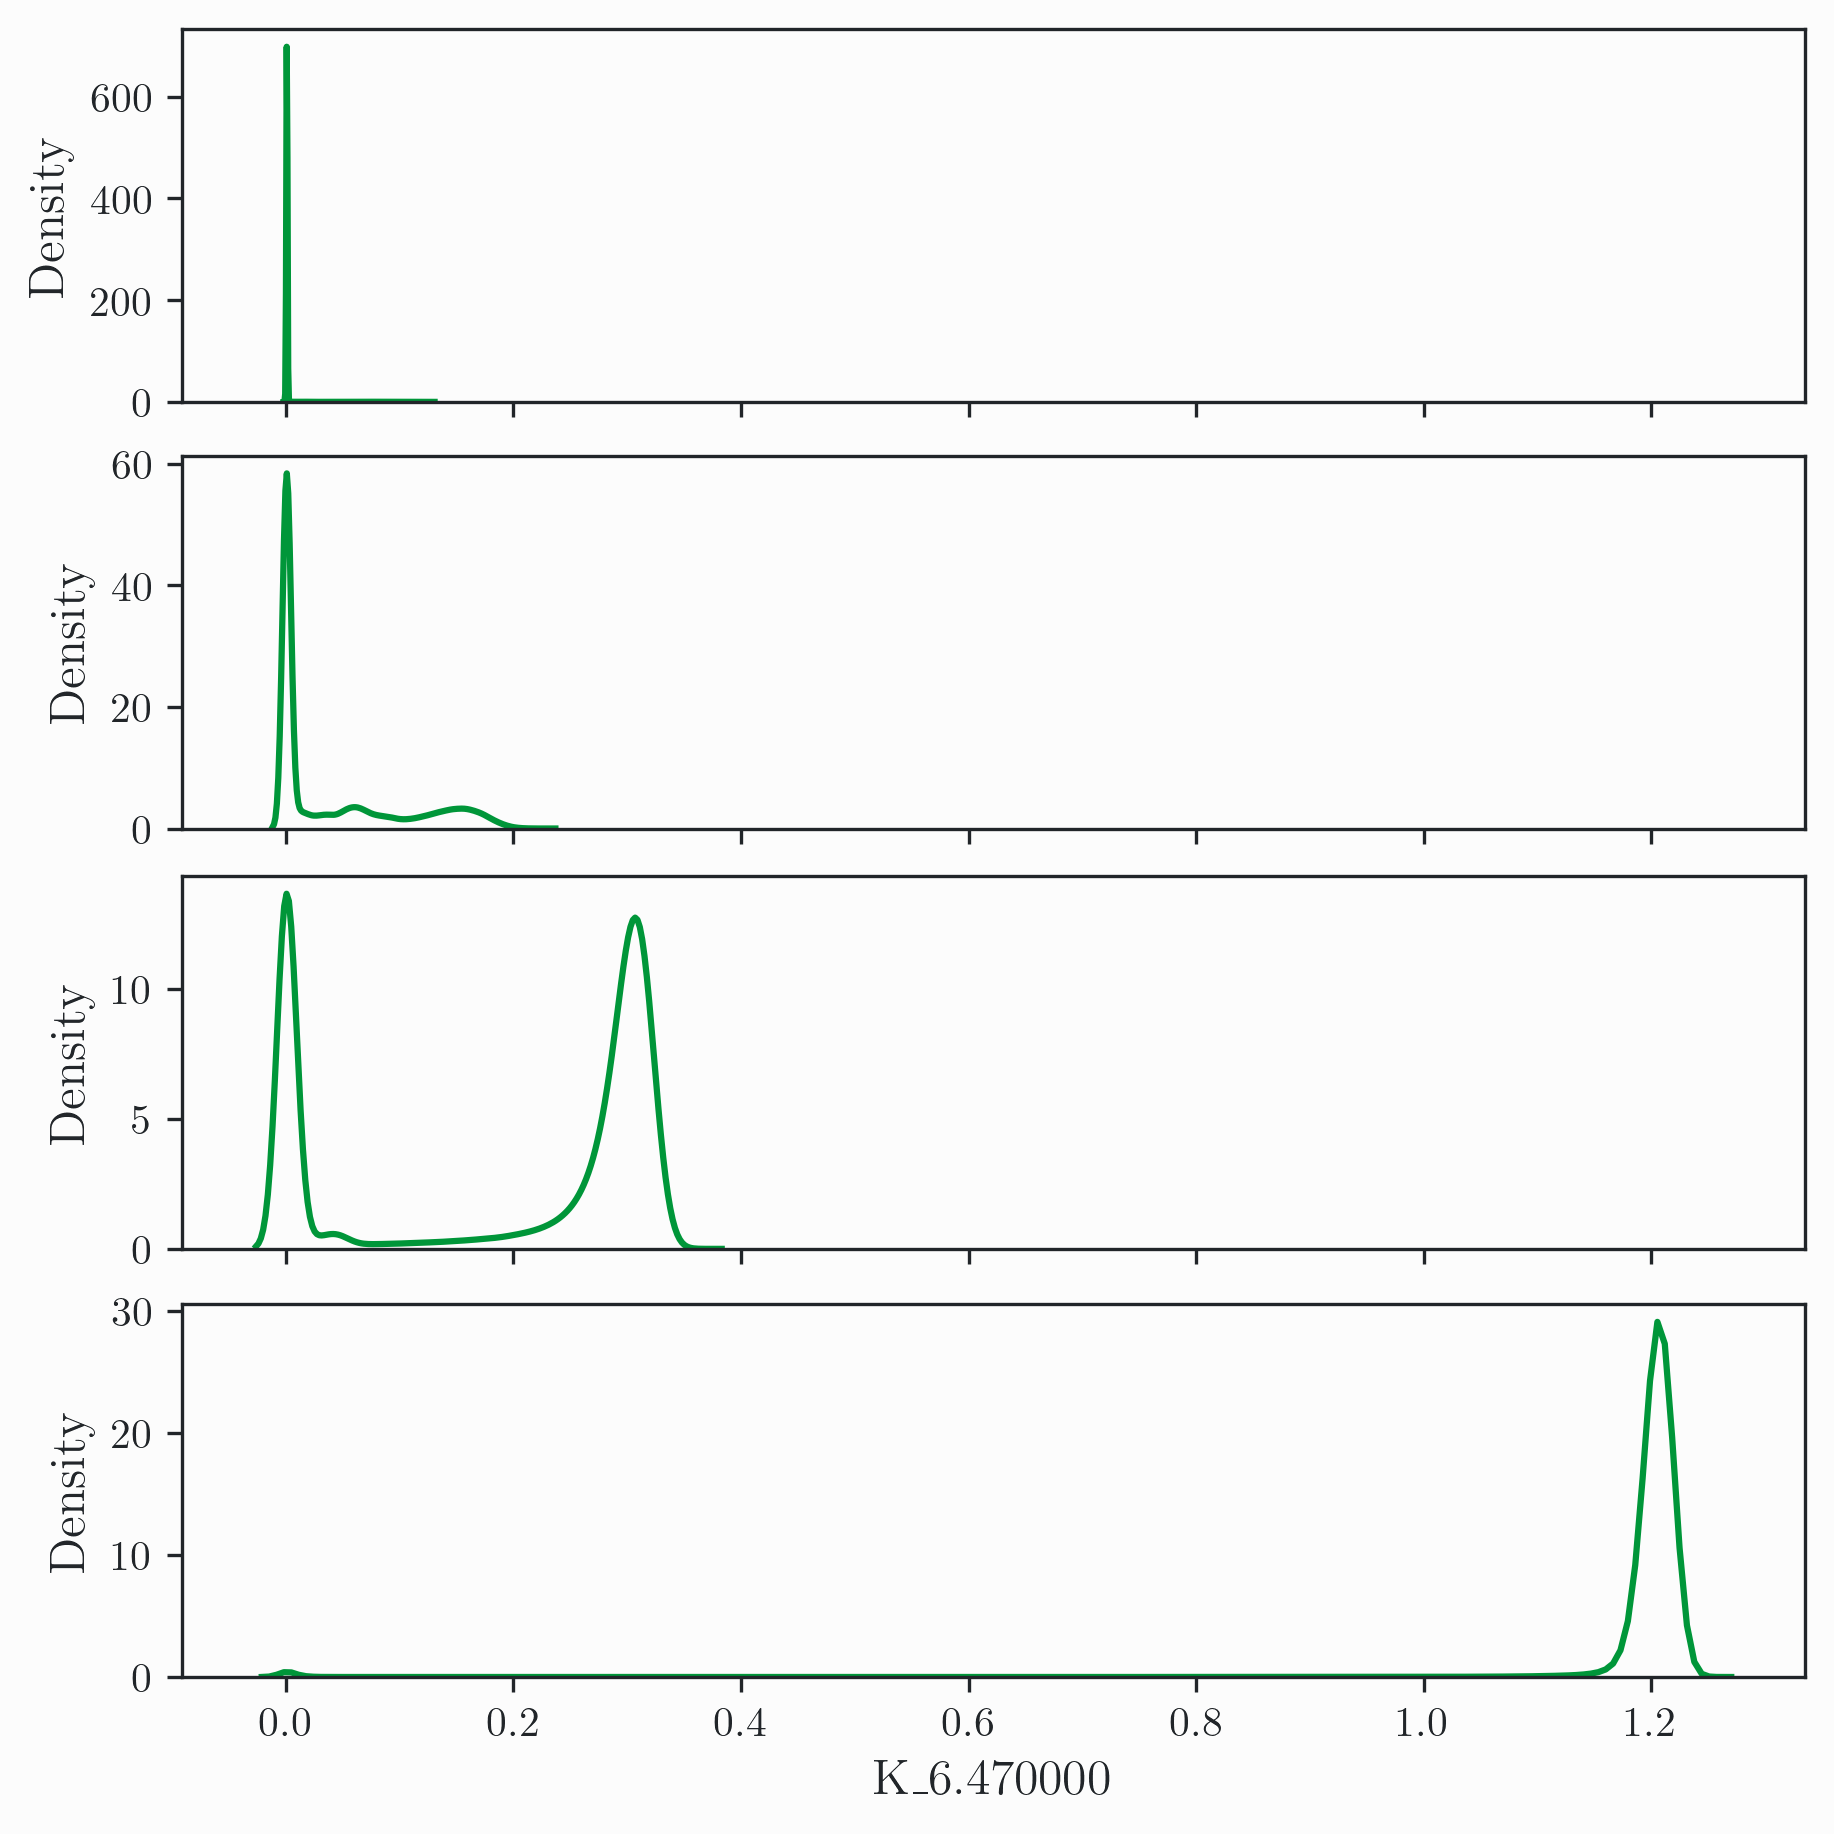

In [15]:
fig, ax = plt.subplot_mosaic([['A'],[ 'B'], ['C'],[ 'D']], figsize=(6, 6), layout='constrained',sharex=True)
sns.kdeplot(data=df["K_0.500000"], ax=ax["A"])
sns.kdeplot(data=df["K_0.971635"], ax=ax["B"])
sns.kdeplot(data=df["K_1.500000"], ax=ax["C"])
sns.kdeplot(data=df["K_6.470000"], ax=ax["D"])

In [16]:
df_test.mean()

K_0.500000    0.001736
K_0.971635    0.044052
K_1.500000    0.196940
K_6.470000    1.193672
dtype: float64

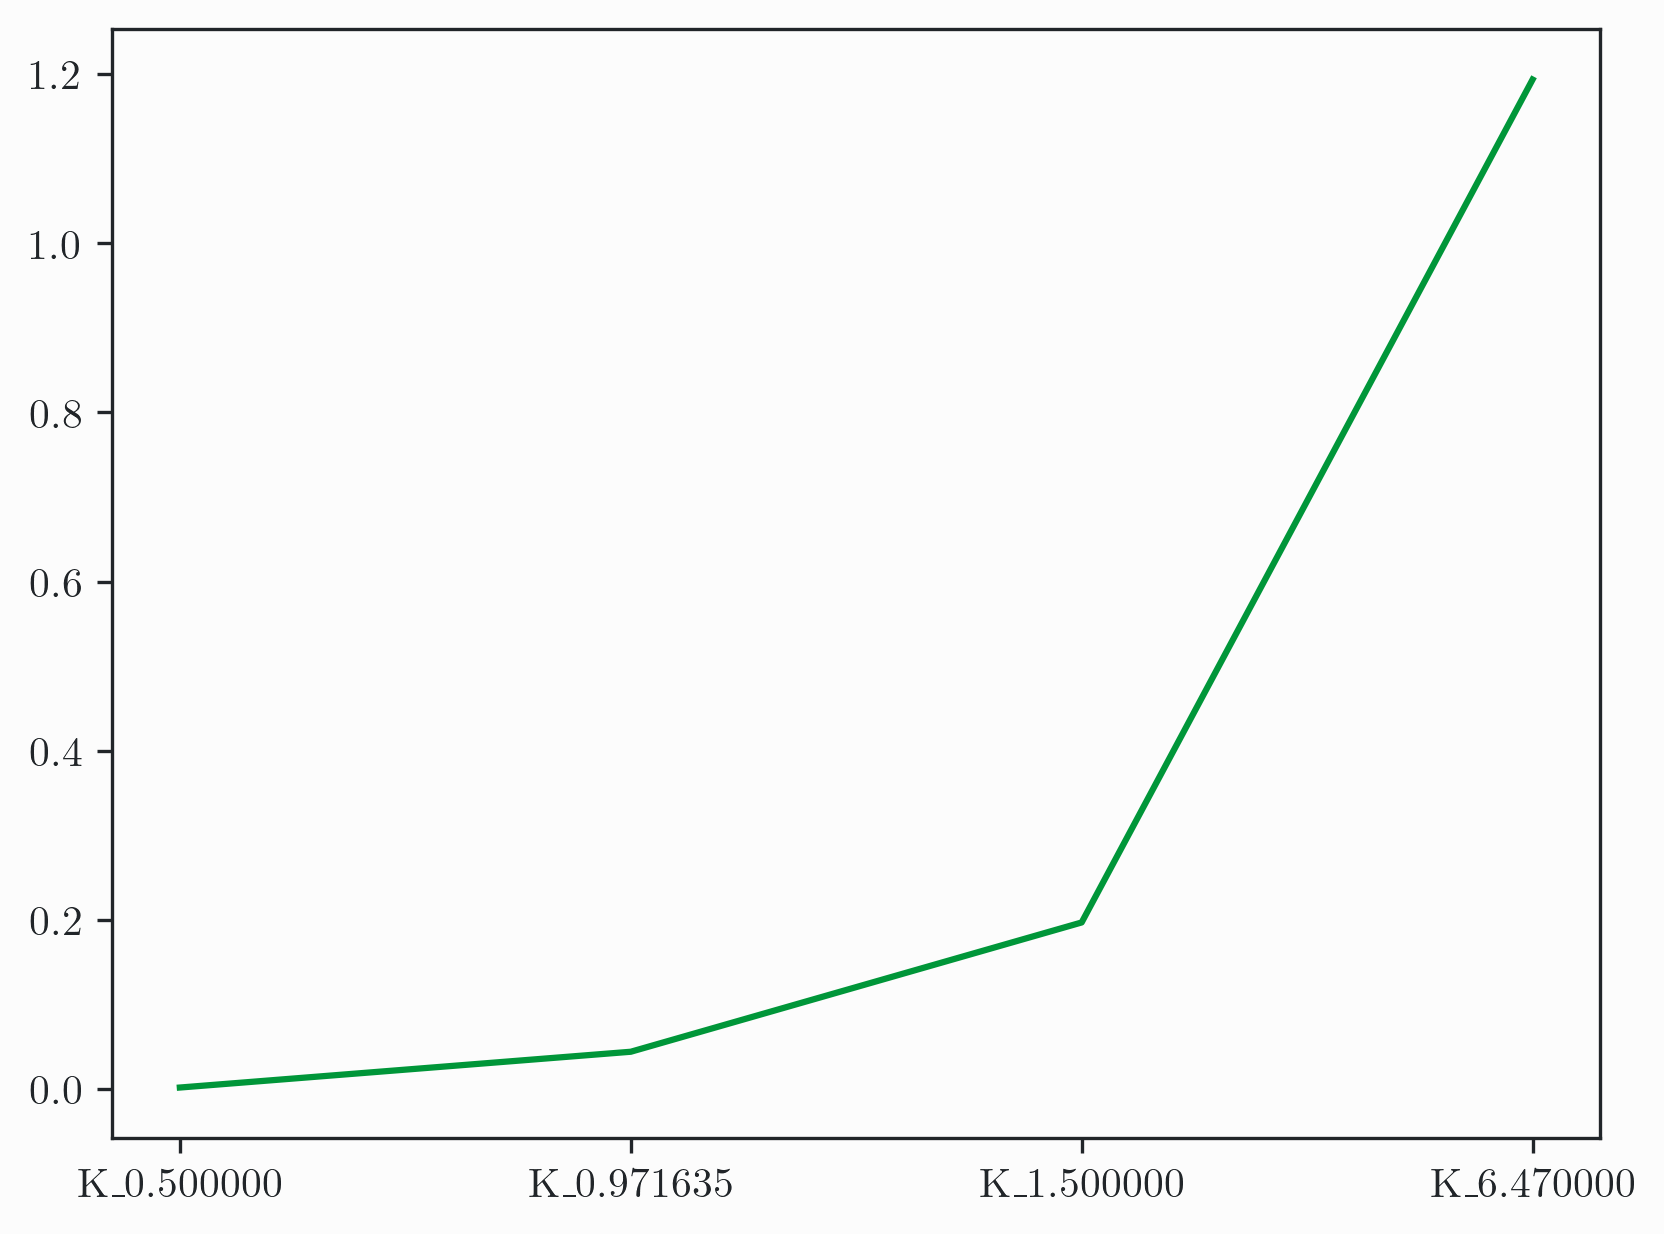

In [17]:
plt.plot(df_test.mean())